# Empirical exploration of linear classifiers

In this lab session we are going to explore binary classification with 2 linear classifiers:

### The Rosenblatt perceptron (1958)
<img src="perceptron_a.png" alt="perceptron unit" style="width: 200px;"/>

The perceptron algorithm was proposed by Rosenblatt in 1958. It is inspired by the biological neuron cell. The perceptron is described by:
- Input: $\mathbf{x}=(x_1,\ldots,x_d)\in\mathbb{R}^d$ 
- Output: $t\in\{-1,1\}$
- Parameters: $\mathbf{w}=(w_1,\ldots,w_d)\in\mathbb{R}^d$ and $w_0\in\mathbb{R}$
- 2 steps:
  + integration: $f(\mathbf{x})=\mathbf{w}\cdot \mathbf{x} + w_0 = W_0 + \sum_{r=1}^d w_r x_r$
  + transfer: $g\circ f(\mathbf{x}) = \textrm{sign}(f(\mathbf{x}))$

The perceptron training algorithm goes as follows:
- Input: A training set $S = \{(\mathbf{x}_1, t_1), \ldots,(\mathbf{x}_m, t_m)\}$
- Initialization: $l=0$, $\mathbf{w}^{(l)}=(0,\ldots,0), \> w_0^{(l)}=0$
- Until convergence or reaching a specified l=L:
  + if $\exists i\in\{1,\ldots,m\}\quad s.t.\quad (\mathbf{w}^{(l)} \cdot \mathbf{x}_i + w_0^{(l)}) t_i \leq 0$ then
  + Update: $\mathbf{w}^{(l+1)}=\mathbf{w}^{(l)}+t_i\mathbf{x}_i$ and $w_0^{(l+1)}=w_0^{(l)}+t_i$

In the separable case the perceptron algorithm is guarantee to converge. In the non-separable case one has to set a maximal number of iterations (to perform early stopping).

The perceptron returns a linear classifier that divides the domain in two halfspaces along the affine boundary with equation $f(\mathbf{x})=\mathbf{w}\cdot \mathbf{x} + w_0 = 0$. 


### Logistic regression
The *sigmoid* function $\sigma:\mathbb{R}\rightarrow ]0,1[$ is defined by: $$\sigma(z)=\frac{1}{1+e^{-z}}$$

In the logistic regression model we learn an hypothesis of the form: $$h(\mathbf{x})=\sigma(\mathbf{w}\cdot \mathbf{x}+w_0)$$ which can be interpreted as the *probability* that $\mathbf{x}$ is labeled 1, 
$$\sigma(\mathbf{w}\cdot \mathbf{x}+w_0) = P(y=1|\mathbf{x}).$$ 

The maximum likelihood estimates of $\mathbf{w}, w_0$ can be obtained with the Iterative reweighted least squares (IRLS) algorithm (see Bishop p. 207)



In [1]:
import numpy as np
from numpy import linalg as la

In [101]:
class Perceptron:
    def __init__(self, max_iter=10):
        self.max_iter = max_iter
        self.weights = np.zeros(2)
        self.bias = 0
        self.dim = -1
    
    def fit(self,X, y):
        "Assumes X is a mxdim matrix and y is a vector of m values in {-1,1}"        

        l = 0
        m = X.shape[0]
        dim = X.shape[1]
        self.dim = dim
        w = np.zeros(dim)
        w_0 = 0
        convergence = False
        
        while not convergence and  (l < self.max_iter):

            i = 0
            found = False
            while not found and i < m:
                if ((X[i] @ w + w_0) * y[i]) <= 0:
                    w  = w + y[i]*X[i]
                    w_0 = w_0 + y[i]
                    l += 1
                    found = True
                else:
                    convergence = True
                i+=1

        print(f"Solution found after {l} iterations.")
        self.weights = w
        self.bias = w_0
        
        
    def predict(self,X):
        "Assumes the model was fitted a first time"

        return np.sign(self.weights.dot(X.transpose())+self.bias)

In [49]:
class Logistic_Regression:
    def __init__(self, max_iter=50, eps_conv=1e-1):
        self.max_iter = max_iter
        self.eps_conv = eps_conv # If too small risk of breaking
        self.weights = np.zeros(2) 
        self.bias = np.zeros(1)
        self.dim = -1
    
    def fit(self,X, y):
        "Assumes X is a mxdim matrix and y is a vector of m values in {0,1}"
        
        m = X.shape[0]
        dim = X.shape[1]
        self.dim = dim
        Xb = np.hstack((X, np.ones((m,1))))
        
        #initialisation : 1 iteration of IRLS algorithm
        w = np.zeros(dim+1)
        w_old = w
        y_pred = 1/2*np.ones((m,))
        R = np.diag(y_pred*(1-y_pred)) # diag(y_n(1-y_n))
        z = Xb.dot(w_old)-la.inv(R).dot(y_pred-y)
        w = la.inv(Xb.T.dot(R).dot(Xb)).dot(Xb.T).dot(R).dot(z)

        # Newton-Raphson algorithm 
        Niter = 1
        while ( (la.norm(w-w_old)/la.norm(w)>self.eps_conv) and (Niter<self.max_iter) ):
            Niter = Niter+1
            y_pred = 1/(1+np.exp(-Xb.dot(w)))
            R = np.diag(y_pred*(1-y_pred)) 
            w_old = w
            z = Xb.dot(w_old)-la.inv(R).dot(y_pred-y)
            w = la.inv(Xb.T.dot(R).dot(Xb)).dot(Xb.T).dot(R).dot(z)
        print("Solution found after", Niter, "iterations.")

        self.weights = w[0:dim]
        self.bias = w[-1]
        
        
    def predict_proba(self,X):
        "Returns the probability of class 1 for each example. Assumes the model was fitted a first time"
        proba = 1/(1+np.exp(-(X.dot(self.weights) + self.bias))) 
        return proba
    
    def predict(self,X):
        "Returns the predicted label for each example. Assumes the model was fitted a first time"
        
        predict_proba = self.predict_proba(X)
        predict = np.array([])
        
        for p in predict_proba:
            if  p >= 0.5:
                predict = np.append(predict, 1)
            else:
                predict = np.append(predict, 0)
        return predict

## iris Data
![3 differents iris species](./iris-machinelearning.png)

### Load the data
It is a classical toy example, hence it is included in scikit-learn package.

In [4]:
from sklearn import datasets
iris = datasets.load_iris()

iris is a dictionary with the following keys:

In [5]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
import pandas as pd
X = pd.DataFrame(iris.data, columns=['sepal length','sepal width', 'petal length','petal width'])
y = pd.Series(iris.target)

<Axes: xlabel='sepal length', ylabel='petal length'>

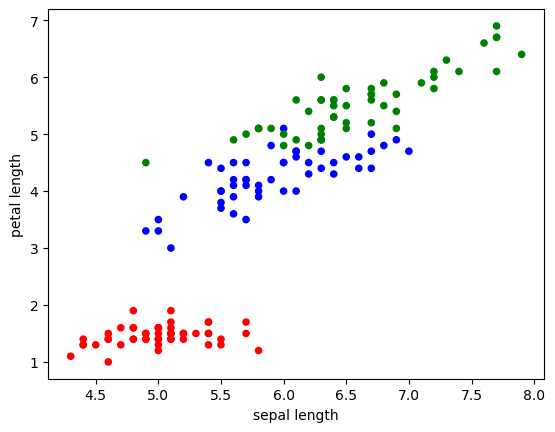

In [8]:
%matplotlib inline
col = {0:"r", 1:"b", 2:"g"}
X.plot.scatter(x="sepal length", y="petal length", c=[col[e] for e in y])

## Questions
> ### Questions:
> 0. Code the perceptron algorithm defined above in the python class below. 
> 1. Modify the fit method of the Logistic_Regression class in order for it to fit also a bias $w_0$ parameter. (HINT: np.hstack and np.ones might be very handy)
> 1. Modify the predict_proba method accordingly and complete the predict method.  
> 1. What is the input domain of the Iris dataset?
> 1. Consider only 2 dimensions (e.g. 'sepal width', 'petal length'): visualise the dataset and the classes
> 1. Recode the classes to get a binary classification problem :
>    * Iris setosa : Class 2
>    * Iris Versicolor & Iris Virginica : Class 1
> 1. Use the coded perceptron and logistic regression to separate the 2 classes Compute the empirical and generalization errors. Visualize the decision functions (use the weights $w$). Comment.
> 1. Recode the classes
>    * Iris Virginica : Class 2
>    * Iris Setosa & Iris Versicolor : Class 1
>    and repeat the previous question for this classification problem. Comment.
> 1. Compare the time complexity of one step of each algorithm. 
> 1. Upload the eggyoke datasets. Use the perceptron and the logistic regression algorithms to solve the classification problem. Compute the empirical and generalization errors. Visualize the decision function (use the weights $w$). What happens? What could be done?

## Question 3:

The input domain of the iris dataset is included in $\mathbb{R}^4$ since we have 4 features which are 'sepal length','sepal width', 'petal length' and 'petal width'

## Question 4:

<Axes: xlabel='sepal length', ylabel='sepal width'>

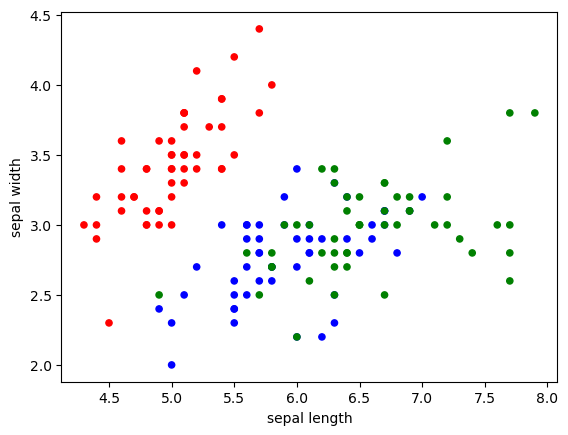

In [9]:
col = {0:"r", 1:"b", 2:"g"}
X.plot.scatter(x="sepal length", y="sepal width", c=[col[e] for e in y])

In [10]:
binary_y = y.map({0: 2, 1: 1, 2: 1})
print(binary_y)

0      2
1      2
2      2
3      2
4      2
      ..
145    1
146    1
147    1
148    1
149    1
Length: 150, dtype: int64


<Axes: xlabel='sepal length', ylabel='sepal width'>

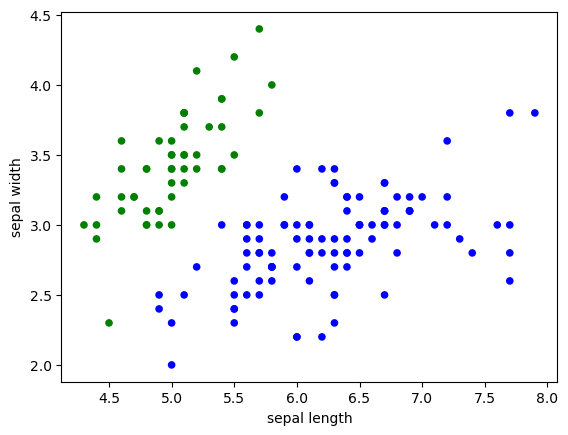

In [11]:
col = {1:"b", 2:"g"}
X.plot.scatter(x="sepal length", y="sepal width", c=[col[e] for e in binary_y])

## Question 6:

In [12]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

def kfold_cross_validation_accuracy(model, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=False)

    train_acc = []
    test_acc = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        train_acc.append(accuracy_score(y_train, y_pred_train))
        test_acc.append(accuracy_score(y_test, y_pred_test))

    return np.mean(train_acc), np.mean(test_acc)


In [99]:
perceptron = Perceptron()

X_perceptron = X.iloc[:, :2].to_numpy()
y_perceptron = binary_y.map({1: -1, 2: 1}).to_numpy()

train_acc, test_acc = kfold_cross_validation_accuracy(perceptron, X_perceptron, y_perceptron)

print("Training accuracy:", train_acc)
print("Generalization accuracy:", test_acc)



Solution found after 2 iterations.
Solution found after 2 iterations.
Solution found after 2 iterations.
Solution found after 2 iterations.
Solution found after 2 iterations.
Training accuracy: 0.5666666666666668
Generalization accuracy: 0.7333333333333333


Solution found after 2 iterations.


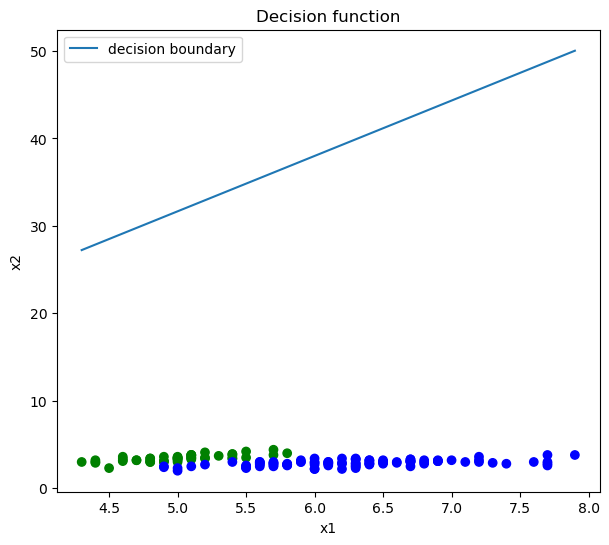

In [100]:
import matplotlib.pyplot as plt

perceptron.fit(X_perceptron, y_perceptron)

weight_perc = perceptron.weights
bias_perc = perceptron.bias


x_1 = np.linspace(X_perceptron[:,0].min(), X_perceptron[:,0].max())
x_2 = -(weight_perc[0]*x_1 + bias_perc) / weight_perc[1]

col = {-1:"b", 1:"g"}

plt.figure(figsize=(7,6))
plt.scatter(X_perceptron[:,0], X_perceptron[:,1], c=[col[e] for e in binary_y.map({1: -1, 2: 1})])
plt.plot(x_1, x_2, label="decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision function")
plt.legend()
plt.show()

In [50]:
logistic = Logistic_Regression()

X_logistic = X.iloc[:, :2].to_numpy()
y_logistic = binary_y.map({1: 0, 2: 1}).to_numpy()

train_acc, test_acc = kfold_cross_validation_accuracy(logistic, X_logistic, y_logistic)

print("Training accuracy:", train_acc)
print("Generalization accuracy:", test_acc)


[0. 0. 0.]
[-1.24970917  2.02066242  0.24480601]
[-1.24970917  2.02066242  0.24480601]
[-2.36279076  3.43518946  1.8689077 ]
[-2.36279076  3.43518946  1.8689077 ]
[-3.703189    4.77331558  4.95185712]
[-3.703189    4.77331558  4.95185712]
[-5.42986946  6.14587117  9.98102798]
[-5.42986946  6.14587117  9.98102798]
[-7.67962344  7.88786713 16.63475227]
[-7.67962344  7.88786713 16.63475227]
[-10.7013619   10.34533595  25.16427474]
[-10.7013619   10.34533595  25.16427474]
[-14.96309185  13.89800624  36.86767549]
[-14.96309185  13.89800624  36.86767549]
[-20.76123472  18.7859145   52.54569573]
[-20.76123472  18.7859145   52.54569573]
[-27.65437489  24.65108622  70.9602065 ]
[-27.65437489  24.65108622  70.9602065 ]
[-35.13549537  31.03650643  90.843182  ]
[-35.13549537  31.03650643  90.843182  ]
[-43.00013546  37.73040892 111.76491488]


LinAlgError: Singular matrix

## Question 7:

In [15]:
new_binary_y = y.map({0: 1, 1: 1, 2: 2})
print(new_binary_y)

0      1
1      1
2      1
3      1
4      1
      ..
145    2
146    2
147    2
148    2
149    2
Length: 150, dtype: int64


In [16]:
perceptron = Perceptron()

X_perceptron = X.to_numpy()
y_perceptron = new_binary_y.map({1: -1, 2: 1}).to_numpy()

train_acc, test_acc = kfold_cross_validation_accuracy(perceptron, X_perceptron, y_perceptron)

print("Training accuracy:", train_acc)
print("Generalization accuracy:", test_acc)

Solution found after 10 iterations.
Solution found after 10 iterations.
Solution found after 10 iterations.
Solution found after 10 iterations.
Solution found after 10 iterations.
Training accuracy: 0.72
Generalization accuracy: 0.6266666666666667


In [17]:
logistic = Logistic_Regression()

X_logistic = X.iloc[:, :2].to_numpy()
y_logistic = new_binary_y.map({1: 0, 2: 1}).to_numpy()

train_acc, test_acc = kfold_cross_validation_accuracy(logistic, X_logistic, y_logistic)

print("Training accuracy:", train_acc)
print("Generalization accuracy:", test_acc)


[[0.25 0.   0.   ... 0.   0.   0.  ]
 [0.   0.25 0.   ... 0.   0.   0.  ]
 [0.   0.   0.25 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.25 0.   0.  ]
 [0.   0.   0.   ... 0.   0.25 0.  ]
 [0.   0.   0.   ... 0.   0.   0.25]]
Solution found after 3 iterations.
[[0.25 0.   0.   ... 0.   0.   0.  ]
 [0.   0.25 0.   ... 0.   0.   0.  ]
 [0.   0.   0.25 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.25 0.   0.  ]
 [0.   0.   0.   ... 0.   0.25 0.  ]
 [0.   0.   0.   ... 0.   0.   0.25]]
Solution found after 4 iterations.
[[0.25 0.   0.   ... 0.   0.   0.  ]
 [0.   0.25 0.   ... 0.   0.   0.  ]
 [0.   0.   0.25 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.25 0.   0.  ]
 [0.   0.   0.   ... 0.   0.25 0.  ]
 [0.   0.   0.   ... 0.   0.   0.25]]
Solution found after 4 iterations.
[[0.25 0.   0.   ... 0.   0.   0.  ]
 [0.   0.25 0.   ... 0.   0.   0.  ]
 [0.   0.   0.25 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.25 0.   0.  ]
 [0.   0.   0.   ... 0.   0.25 0.  ]
 [0.   0.   0.   ... 

## Question 8:

For the perceptron algorithm, one iteration of the while loop goes like this in the worst case: 

1. `pos = np.arange(m)` which has a complexity of <strong>O(1)</strong>
2. `tmp = np.array([((X[i] @ w + w_0) * y[i]) <= 0 for i in pos])` where the scalar product cost d operations and we repeat this operation m times. We obtain then a complexity of <strong>O(m.d)</strong>
3. `indexs = np.where(tmp)[0]` which check a boolean array of size m. Therefore, the cost will be <strong>O(m)</strong>
4. ```python
    if np.size(indexs) > 0:
        i = indexs[0]
        w  = w + y[i] * X[i]
        w_0 = w_0 + y[i]
        l += 1

In this part of the code the line which has the most computation is `w  = w + y[i] * X[i]`. Indeed, this is an addition and a multiplication of a vector and a scalar having a time complexity of <strong>O(d)</strong>

Finally, the time complexity of one step of the perceptron algorithm is <strong>O(1)</strong> + <strong>O(m.d)</strong> + <strong>O(m)</strong> + <strong>O(d)</strong> = <strong>O(m.d)</strong>

For the Logistic Regresion algorithm, one iteration of the while loop goes like this in the worst case: 

1. `Niter = Niter+1` and `w_old = w` are just assignments so they have constant time
2. `y_pred = 1/(1+np.exp(-Xb.dot(w)))`. First we compute the product beetween two matrices. Hence, the time complexity will be <strong>O(m.(d+1))</strong> = <strong>O(m.d)</strong> (since we added the bias to X). After this computation, we apply the sigmoid function for each term of the new vector we got before, giving us at the end a time complexity of <strong>O(m)</strong> + <strong>O(m.d)</strong> = <strong>O(m.d)</strong>
3. `R = np.diag(y_pred*(1-y_pred))` 

## Question 9:

In [67]:
data_train = pd.read_csv("eggyoke_traindata.csv")

X_train = data_train[["x_1", "x_2"]].to_numpy()
y_train = data_train["y"]

y_perc_train = y_train.to_numpy()
y_log_train  = y_train.map({-1: 0,  1: 1}).to_numpy()

data_test = pd.read_csv("eggyoke_testdata.csv")

X_test = data_test[["x_1", "x_2"]].to_numpy()
y_test = data_test["y"]

y_perc_test = y_test.to_numpy()
y_log_test  = y_test.map({-1: 0,  1: 1}).to_numpy()

In [68]:
model = Perceptron(max_iter=50)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Empirical accuracy score = {accuracy_score(y_pred_train, y_perc_train)}")
print(f"Generalization accuracy score = {accuracy_score(y_pred_test, y_perc_test)}")

Solution found after 50 iterations.
Empirical accuracy score = 0.5571428571428572
Generalization accuracy score = 0.5592417061611374


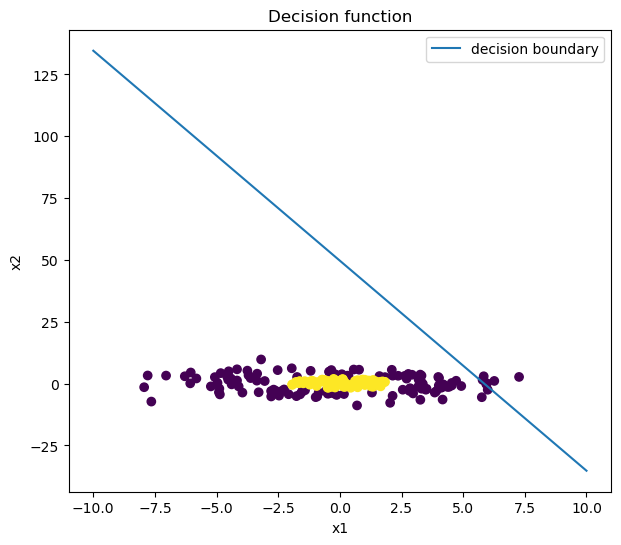

In [98]:
weight_perc = model.weights
bias_perc = model.bias


x_1 = np.linspace(-10, 10)
x_2 = -(weight_perc[0]*x_1 + bias_perc) / weight_perc[1]

plt.figure(figsize=(7,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_perc_train)
plt.plot(x_1, x_2, label="decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision function")
plt.legend()
plt.show()

In [57]:
model = Logistic_Regression(eps_conv=0.9)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Empirical accuracy score = {accuracy_score(y_pred_train, y_log_train)}")
print(f"Generalization accuracy score = {accuracy_score(y_pred_test, y_log_test)}")

[0. 0. 0.]
[ 0.02284607  0.07717144 -2.6876355 ]
Solution found after 2 iterations.
Empirical accuracy score = 0.5857142857142857
Generalization accuracy score = 0.5924170616113744
